In [2]:
#데이터 분석
import numpy as np
import pandas as pd

#데이터 시각화
import seaborn as sns
import matplotlib.pyplot as plt

#머신러
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

In [3]:
iris = load_iris()

In [4]:
df = pd.DataFrame(iris.data, columns = iris.feature_names)

# 3. train/test Split

In [7]:
df.to_csv("./data/iris_df.csv", index=False)

In [8]:
df=pd.read_csv("./data/iris_df.csv")

In [9]:
df

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2
...,...,...,...,...
145,6.7,3.0,5.2,2.3
146,6.3,2.5,5.0,1.9
147,6.5,3.0,5.2,2.0
148,6.2,3.4,5.4,2.3


In [10]:
#y : 소문자, X : 대문자
y = df['petal width (cm)']
X = df.drop(['petal width (cm)'], axis = 1)

In [11]:
y.head()

0    0.2
1    0.2
2    0.2
3    0.2
4    0.2
Name: petal width (cm), dtype: float64

In [12]:
X.head()

,sepal length (cm),sepal width (cm),petal length (cm)
0,5.1,3.5,1.4
1,4.9,3.0,1.4
2,4.7,3.2,1.3
3,4.6,3.1,1.5
4,5.0,3.6,1.4


# train data/ test data 비율
6:4, 7:3, 8:2

In [18]:
#random_state : 데이터를 스플릿할때 일정한 기준을 가지고 스플릿하도록
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state=42 )

In [19]:
lr_model = LinearRegression()

In [20]:
lr_model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [21]:
y_pred = lr_model.predict(X_test)

In [22]:
from sklearn.metrics import mean_squared_error, r2_score


In [23]:
mse = mean_squared_error(y_test, y_pred)

In [24]:
mse

0.046332603325764395

In [25]:
r2 = r2_score(y_test, y_pred)

In [26]:
r2

0.9271105193357899

<Axes: >

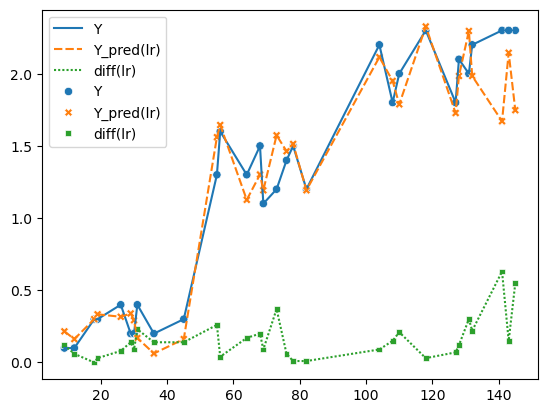

In [27]:
lr_df = pd.DataFrame(data = {'Y' : y_test, 'Y_pred(lr)' : y_pred, 
                             'diff(lr)' : np.round(np.abs(y_test - y_pred),2)})
sns.lineplot(data = lr_df)
sns.scatterplot(data = lr_df)